In [52]:
import numpy as np

def cptFormulaXAb(Ab, t, x01):
    from scipy.linalg import expm
    """
    Compute the formula for x(t) = e^(At) * x0 + b using the matrix exponential.
    
    Parameters:
    n : size of the matrix
    Ab : augmented matrix containing A and b
    t : time variable
    x01 : initial condition vector
    
    Returns:
    The computed value of x(t).
    """
    # Compute the matrix exponential
    exp_At = expm(Ab * t)  # Placeholder for actual matrix exponential computation
    return exp_At @ x01

# minTime: 1.11875e-14 b: [0, 0, 1.45037, 1.44493] A: [0, 0, 10000, 0, 0, 0, 0, 10000, -121652, -29.6662, -24330.5, -5.93325, -29.6662, -121634, -5.93325, -24326.9] x0: [0, 0, -0.462727, -0.463499]
def findMinRootBisection(n, A, b, x0, maxIter=300, tolerance=1e-10):
    """
    Find the minimum root of a e^At * x0 + b = 0 using the bisection method.
    
    Parameters:
    A : exponential matrix coefficients
    b : constant term
    x0 : initial guess for the root
    minTime : minimum time to consider for the root
    
    Returns:
    The minimum root found.
    """
    n2 = 2 * n
    A = np.reshape(A, (n2, n2))
    b = np.reshape(b, (n2, 1))
    x0 = np.reshape(x0, (n2, 1))
    top = np.c_[A, b]
    bottom = np.c_[np.zeros((1, n2)), [1]]
    Ab = np.r_[top, bottom]
    eigvals = np.linalg.eigvals(Ab)
    alphaVec = np.unique(-np.sort(-np.abs(eigvals.imag), ), sorted=True)
    alphaVecNonZero = alphaVec[alphaVec > 0]
    print(alphaVecNonZero)
    pois = np.zeros(4 * len(alphaVecNonZero))
    for i in range(len(alphaVecNonZero)):
        temp = np.pi / alphaVecNonZero[i]
        pois[4 * i] = 0.5 * temp
        pois[4 * i + 1] = temp
        pois[4 * i + 2] = 1.5 * temp
        pois[4 * i + 3] = 2 * temp
    pois = np.sort(pois)
    print(pois)
    
    x01 = np.r_[x0, [[1]]]
    lowerBound = 1e-12
    upperBound = 0.1
    negativeDepthExists = False
    for poi in pois:
      x1t = cptFormulaXAb(Ab, poi, x01)
      if np.any(x1t[:n] < 0):
        upperBound = poi
        negativeDepthExists = True
        break
      else:
        lowerBound = poi
    print("lowerBound:", lowerBound, "upperBound:", upperBound)
    if not negativeDepthExists:
      print("No negative depth found in pois, returning minTime")
      return -1
    m = (lowerBound + upperBound) / 2
    i = 0
    for i in range(maxIter):
      m = (lowerBound + upperBound) / 2
      x1t = cptFormulaXAb(Ab, m, x01)
      if np.any(np.abs(x1t[:n]) < tolerance) and not np.any(x1t[:n] < -tolerance):
        break
      if not np.any(x1t[:n] < 0):
        lowerBound = m
      else:
        upperBound = m
    if i == maxIter:
      print(i, maxIter)
      m = -1
    return m

A = [0, 0, 10000, 0, 0, 0, 0, 10000, -121652, -29.6662, -24330.5, -5.93325, -29.6662, -121634, -5.93325, -24326.9]
b = [0, 0, 1.45037, 1.44493]
x0 = [0, 0, -0.462727, -0.463499]
print(findMinRootBisection(2, A, b, x0, 2000))
print(np.linalg.eig(np.array([[0, 10000], [-20000, -100000]])))  # Example usage of numpy.linalg.eig
print(np.linalg.eig(np.array([[0, 1000], [-200000, -100000]])))  # Example usage of numpy.linalg.eig


[32683.6960635  32690.87289385]
[4.80499965e-05 4.80605475e-05 9.60999929e-05 9.61210950e-05
 1.44149989e-04 1.44181642e-04 1.92199986e-04 1.92242190e-04]
lowerBound: 1e-12 upperBound: 4.804999645911795e-05
1.0000000000000002e-12
EigResult(eigenvalues=array([ -2041.68476687, -97958.31523313]), eigenvectors=array([[ 0.97978738, -0.10155644],
       [-0.2000417 ,  0.99482978]]))
EigResult(eigenvalues=array([ -2041.68476687, -97958.31523313]), eigenvectors=array([[ 0.4398643 , -0.01020789],
       [-0.89806425,  0.9999479 ]]))


Eq(x(t), 0.00049 - 4.00527682652007e-5*exp(-99999.7999996*t) + 0.000202320768265201*exp(-0.2000004000016*t)) 4.0052688159504*exp(-99999.7999996*t) - 4.04642345816712e-5*exp(-0.2000004000016*t)


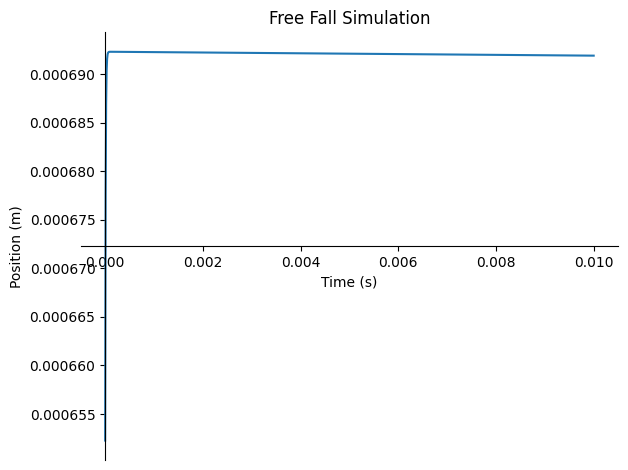

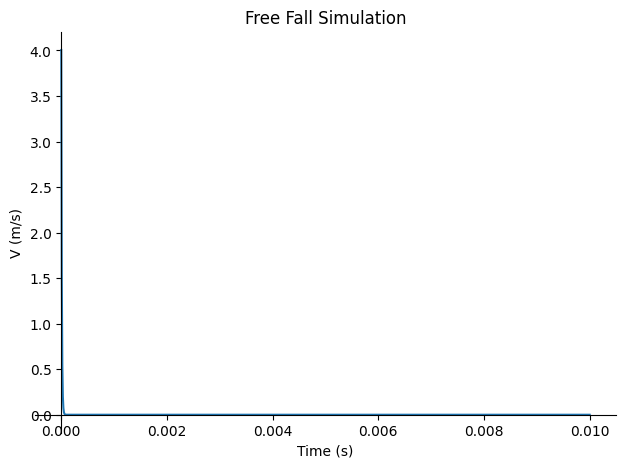

In [ ]:
import sympy as sp
t = sp.symbols('t')
x = sp.Function('x')(t)
diff_eq = sp.Eq(sp.Derivative(x, t, 2) + 1e5 * sp.Derivative(x, t) + 2e4 * x, 9.8)
x0 = [0.000652268, -3.31293e-05]
solnp = sp.dsolve(diff_eq, x, ics={x.subs(t, 0): x0[0], sp.Derivative(x, t).subs(t, 1): x0[1]})
print(solnp, sp.diff(solnp.rhs, t))

sp.plot(solnp.rhs, (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='Position (m)', show=True)
sp.plot(sp.diff(solnp.rhs, t), (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='V (m/s)', show=True)

Eq(x(t), 0.00049 - 4.00527682652007e-5*exp(-99999.7999996*t) + 0.000202320768265201*exp(-0.2000004000016*t)) 4.0052688159504*exp(-99999.7999996*t) - 4.04642345816712e-5*exp(-0.2000004000016*t)


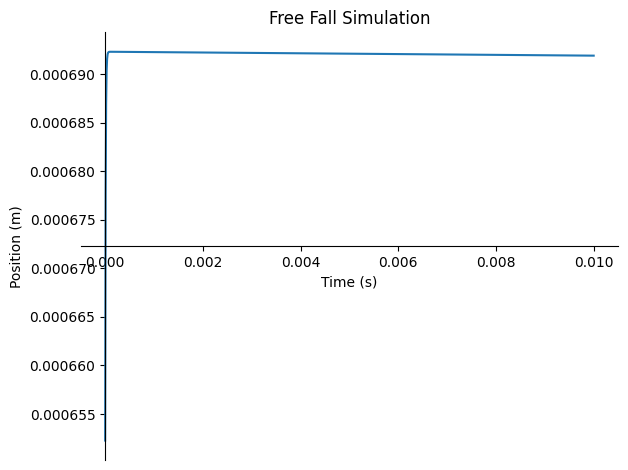

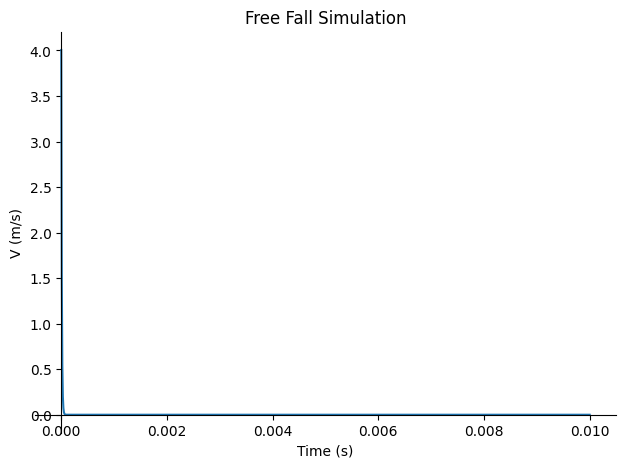

In [ ]:
import sympy as sp
t = sp.symbols('t')
x = sp.Function('x')(t)
diff_eq = sp.Eq(sp.Derivative(x, t, 2) + 1e5 * sp.Derivative(x, t) + 2e5 * x, 9.8)
x0 = [0.0000652268, -3.31293e-05]
solnp = sp.dsolve(diff_eq, x, ics={x.subs(t, 0): x0[0], sp.Derivative(x, t).subs(t, 1): x0[1]})
print(solnp, sp.diff(solnp.rhs, t))

sp.plot(solnp.rhs, (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='Position (m)', show=True)
sp.plot(sp.diff(solnp.rhs, t), (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='V (m/s)', show=True)